In [93]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from tensorflow import keras
from tensorflow.keras.layers import Dense,Input , Flatten , Dropout , BatchNormalization , ReLU, Conv2D, MaxPool2D, GlobalAvgPool2D , RandomFlip ,RandomRotation, RandomZoom , SpatialDropout2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam , SGD
from tensorflow.keras.regularizers import l2 , l1
from tensorflow.keras.datasets import mnist , fashion_mnist
from tensorflow.keras.callbacks import EarlyStopping , ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.losses import categorical_crossentropy, binary_crossentropy, binary_focal_crossentropy,categorical_focal_crossentropy
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score, roc_curve,auc
from sklearn.utils.class_weight import compute_class_weight
from sklearn.datasets import load_iris , make_classification
from tensorflow.keras.utils import to_categorical , image_dataset_from_directory
import os

In [94]:
path='/kaggle/input/datasets/mianaftab/eurosat'

In [95]:
print(os.listdir(path))

['2750']


In [96]:
DATA_DIR = "/kaggle/input/datasets/mianaftab/eurosat/2750"

In [97]:
import os

class_names = sorted(os.listdir(DATA_DIR))
print("Classes:", class_names)
print("Number of classes:", len(class_names))

Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Number of classes: 10


In [98]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

Found 27000 files belonging to 10 classes.
Using 21600 files for training.
Found 27000 files belonging to 10 classes.
Using 5400 files for validation.


In [99]:
class_names = train_ds.class_names

print(class_names)
print("Number of classes:", len(class_names))

['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Number of classes: 10


In [100]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)

val_ds = val_ds.cache().prefetch(AUTOTUNE)

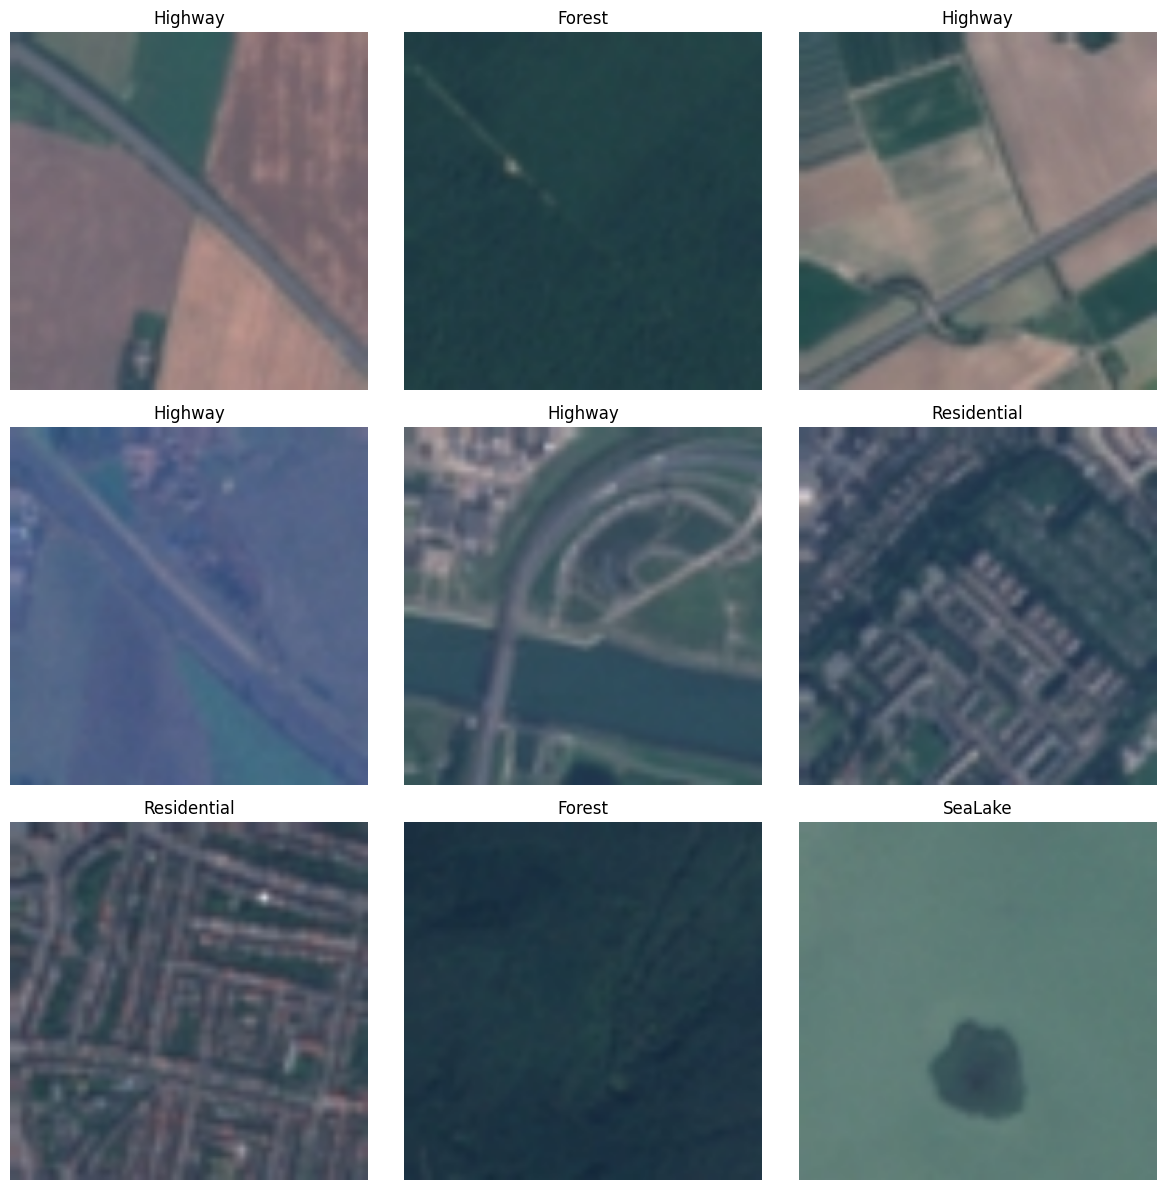

In [101]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,12))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [102]:
images, labels = next(iter(train_ds))

print(images.shape)
print(labels.shape)

(32, 224, 224, 3)
(32,)


In [103]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.10),
], name="data_augmentation")

In [104]:
from tensorflow.keras.applications import MobileNetV2
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

In [105]:
model = tf.keras.Sequential([

    layers.Input(shape=(224,224,3)),

    data_augmentation,

    layers.Rescaling(1./255),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.BatchNormalization(),

    layers.Dropout(0.4),

    layers.Dense(
        256,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(1e-4)
    ),

    layers.Dropout(0.3),

    layers.Dense(10, activation="softmax")

])

In [106]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [107]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
)

In [108]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

checkpoint = keras.callbacks.ModelCheckpoint(
    "best_mobilenetv2.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)
callbacks = [
    early_stop,
    reduce_lr,
    checkpoint
]

In [109]:
history = model.fit(train_ds,validation_data=val_ds,epochs=15,callbacks=callbacks)

Epoch 1/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.7690 - loss: 0.8291
Epoch 1: val_accuracy improved from None to 0.89907, saving model to best_mobilenetv2.keras

Epoch 1: finished saving model to best_mobilenetv2.keras
675/675 ━━━━━━━━━━━━━━━━━━━━ 55s 66ms/step - accuracy: 0.8151 - loss: 0.6603 - val_accuracy: 0.8991 - val_loss: 0.3581 - learning_rate: 0.0010
Epoch 2/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8498 - loss: 0.5116
Epoch 2: val_accuracy improved from 0.89907 to 0.90444, saving model to best_mobilenetv2.keras

Epoch 2: finished saving model to best_mobilenetv2.keras
675/675 ━━━━━━━━━━━━━━━━━━━━ 44s 65ms/step - accuracy: 0.8557 - loss: 0.4974 - val_accuracy: 0.9044 - val_loss: 0.3382 - learning_rate: 0.0010
Epoch 3/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8627 - loss: 0.4677
Epoch 3: val_accuracy improved from 0.90444 to 0.91148, saving model to best_mobilenetv2.keras

Epoch 3: finished saving model to best_mobilenetv2.ker

In [129]:
base_model.trainable = True

for layer in base_model.layers[:-80]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9706 - loss: 0.1216
Epoch 1: val_accuracy improved from 0.96296 to 0.96407, saving model to best_mobilenetv2.keras

Epoch 1: finished saving model to best_mobilenetv2.keras
675/675 ━━━━━━━━━━━━━━━━━━━━ 66s 84ms/step - accuracy: 0.9716 - loss: 0.1203 - val_accuracy: 0.9641 - val_loss: 0.1531 - learning_rate: 1.0000e-06
Epoch 2/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9702 - loss: 0.1267
Epoch 2: val_accuracy did not improve from 0.96407
675/675 ━━━━━━━━━━━━━━━━━━━━ 56s 83ms/step - accuracy: 0.9712 - loss: 0.1222 - val_accuracy: 0.9633 - val_loss: 0.1532 - learning_rate: 1.0000e-06
Epoch 3/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9711 - loss: 0.1200
Epoch 3: val_accuracy did not improve from 0.96407
675/675 ━━━━━━━━━━━━━━━━━━━━ 56s 83ms/step - accuracy: 0.9712 - loss: 0.1200 - val_accuracy: 0.9631 - val_loss: 0.1540 - learning_rate: 1.0000e-06
Epoch 4/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [130]:
test_loss, test_accuracy = model.evaluate(val_ds)

print(f"\nValidation Loss     : {test_loss:.4f}")
print(f"Validation Accuracy : {test_accuracy*100:.2f}%")

169/169 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - accuracy: 0.9641 - loss: 0.1531

Validation Loss     : 0.1531
Validation Accuracy : 96.41%


In [134]:
acc = history.history["accuracy"] + fine_tune_history.history["accuracy"]
val_acc = history.history["val_accuracy"] + fine_tune_history.history["val_accuracy"]

loss = history.history["loss"] + fine_tune_history.history["loss"]
val_loss = history.history["val_loss"] + fine_tune_history.history["val_loss"]

epochs = range(1, len(acc) + 1)

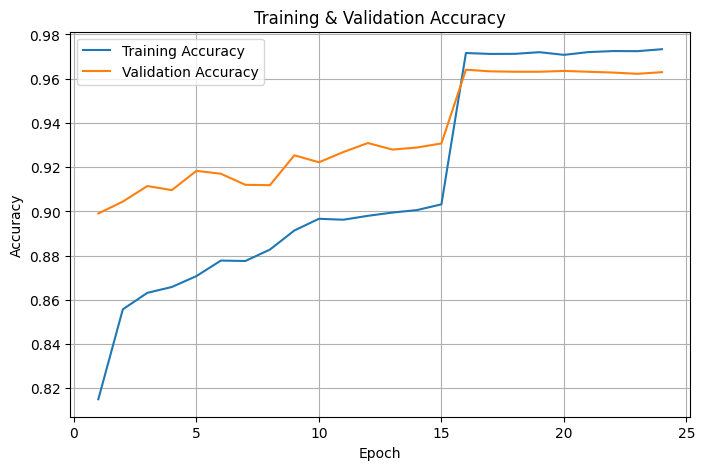

In [135]:
plt.figure(figsize=(8,5))
plt.plot(epochs, acc, label="Training Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")
plt.title("Training & Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

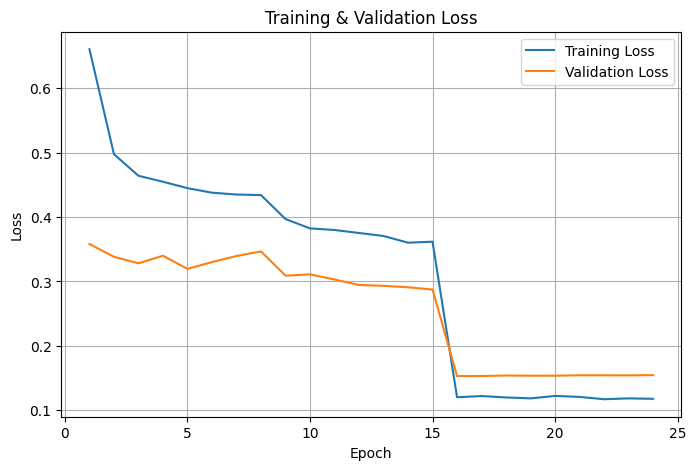

In [136]:
plt.figure(figsize=(8,5))
plt.plot(epochs, loss, label="Training Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.title("Training & Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [137]:
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

                      precision    recall  f1-score   support

          AnnualCrop       0.96      0.95      0.96       597
              Forest       0.97      0.98      0.98       600
HerbaceousVegetation       0.95      0.93      0.94       557
             Highway       0.94      0.94      0.94       493
          Industrial       0.99      0.98      0.99       512
             Pasture       0.94      0.94      0.94       374
       PermanentCrop       0.93      0.96      0.94       491
         Residential       0.98      1.00      0.99       607
               River       0.96      0.96      0.96       547
             SeaLake       0.99      0.99      0.99       622

            accuracy                           0.96      5400
           macro avg       0.96      0.96      0.96      5400
        weighted avg       0.96      0.96      0.96      5400



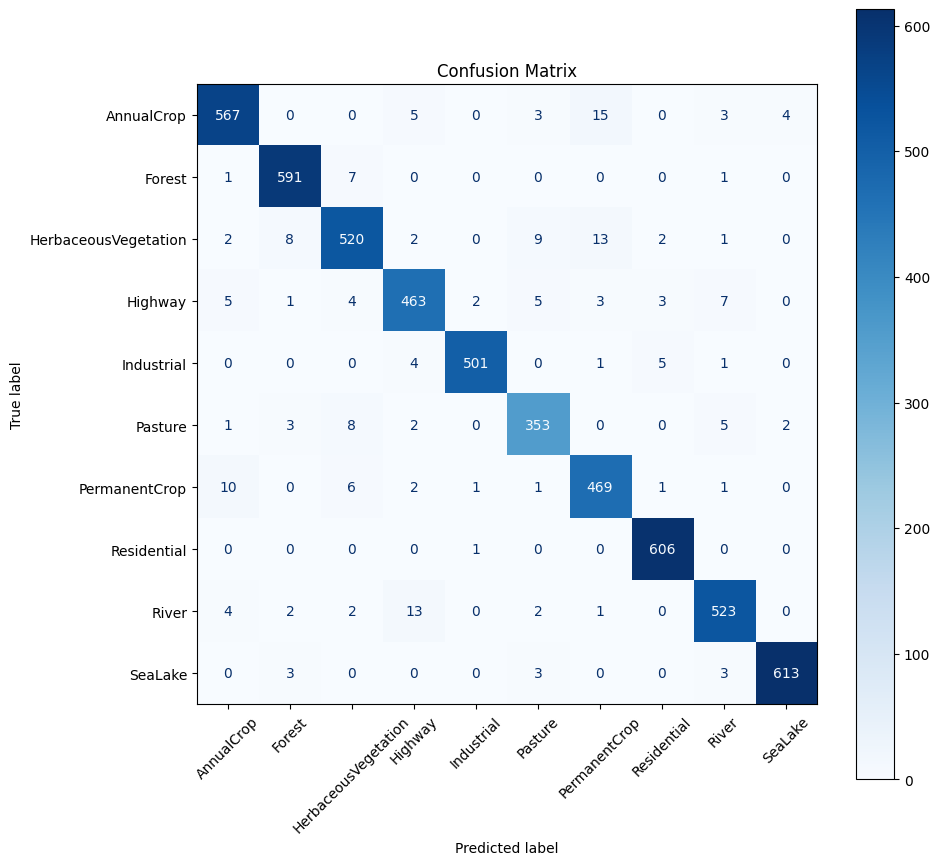

In [138]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10,10))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()